# EveryQuery vs EIC: Multi-Duration Results

Single analysis notebook for the updated preprint. Loads EQ multi-duration eval,
EIC baseline, and prevalence data, then runs verification, statistical comparisons,
loss characterization, and generates all figures inline.

## Setup and Data Loading

In [3]:
from collections import Counter
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import polars as pl
from scipy import stats as sp_stats

matplotlib.rcParams.update({
    "font.size": 8,
    "font.family": "sans-serif",
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

%matplotlib inline

In [4]:
REPO = Path(".").resolve().parent
DATA = REPO / "data"

EQ_MODEL_DIR = DATA / "outputs" / "2026-04-02" / "23-43-54"
EQ_PARQUET = EQ_MODEL_DIR / "eval" / "best" / "eval_aucs_held_out_20260410_192213.parquet"
EIC_PARQUET = DATA / "baselines" / "eic" / "temporal_auc_results_10000_ID__8db2be6fadf8.parquet"
PREVALENCE_CSV = DATA / "held_out_prevalence_7573f855c4b050a9d79d57fefd8a139c.csv"

DURATIONS = [30, 90, 180, 365, 730]
TRAINED_DURATIONS = {30, 180}
OOD_DURATIONS = {90, 365, 730}
INTERP_OOD = {90}
EXTRAP_OOD = {365, 730}

In [5]:
# Load EQ
eq_raw = pl.read_parquet(EQ_PARQUET)
eq_raw = eq_raw.with_columns(
    pl.when(pl.col("duration_days") == 731)
    .then(730)
    .otherwise(pl.col("duration_days"))
    .alias("duration_days")
)
print(f"EQ raw: {eq_raw.shape}")

# Load EIC (wide -> long)
eic_wide = pl.read_parquet(EIC_PARQUET)
eic_wide = eic_wide.with_columns(
    (pl.col("duration").dt.total_microseconds() / (1e6 * 86400))
    .cast(pl.Int64)
    .alias("duration_days")
)
auc_cols = [c for c in eic_wide.columns if c.startswith("AUC/")]
eic_raw = eic_wide.unpivot(
    on=auc_cols,
    index=["duration_days"],
    variable_name="code_slug_raw",
    value_name="eic_auc",
).with_columns(
    pl.col("code_slug_raw").str.strip_prefix("AUC/").alias("code_slug")
).drop("code_slug_raw")
print(f"EIC unpivoted: {eic_raw.shape}")

# Load prevalence
prev_raw = pl.read_csv(PREVALENCE_CSV)
prev_raw = prev_raw.with_columns(
    pl.when(pl.col("duration_days") == 731)
    .then(730)
    .otherwise(pl.col("duration_days"))
    .alias("duration_days")
)
print(f"Prevalence raw: {prev_raw.shape}")

EQ raw: (205, 11)
EIC unpivoted: (200, 3)
Prevalence raw: (205, 3)


In [6]:
# Inner join EQ + EIC
joined_raw = eq_raw.join(eic_raw, on=["code_slug", "duration_days"], how="inner")
print(f"After join: {joined_raw.shape[0]} rows")

# Filter nulls, compute delta
joined = (
    joined_raw
    .filter(pl.col("occurs_auc").is_not_null() & pl.col("eic_auc").is_not_null())
    .with_columns(
        (pl.col("occurs_auc") - pl.col("eic_auc")).alias("delta_auc")
    )
)
print(f"After null filter: {len(joined)} rows")

# Join prevalence
df = joined.join(prev_raw, on=["code", "duration_days"], how="inner")
print(f"After prevalence join: {len(df)} rows")

After join: 200 rows
After null filter: 199 rows
After prevalence join: 199 rows


## Data Verification

In [7]:
print("Row counts at each stage:")
print(f"  EQ raw:             {eq_raw.shape[0]}")
print(f"  EIC unpivoted:      {eic_raw.shape[0]}")
print(f"  After inner join:   {joined_raw.shape[0]}")
print(f"  After null filter:  {len(joined)}")
print(f"  After prev join:    {len(df)}")

Row counts at each stage:
  EQ raw:             205
  EIC unpivoted:      200
  After inner join:   200
  After null filter:  199
  After prev join:    199


In [8]:
# Code slug overlap
eq_slugs = set(eq_raw["code_slug"].unique().to_list())
eic_slugs = set(eic_raw["code_slug"].unique().to_list())
print(f"EQ codes: {len(eq_slugs)}, EIC codes: {len(eic_slugs)}")
print(f"EQ codes not in EIC: {eq_slugs - eic_slugs}")
print(f"EIC codes not in EQ: {eic_slugs - eq_slugs}")

# Duration coverage
eq_durs = sorted(eq_raw["duration_days"].unique().to_list())
eic_durs = sorted(eic_raw["duration_days"].unique().to_list())
print(f"\nEQ durations:  {eq_durs}")
print(f"EIC durations: {eic_durs}")

EQ codes: 41, EIC codes: 40
EQ codes not in EIC: {'TIMELINE_START__6d59af27ad'}
EIC codes not in EQ: set()

EQ durations:  [30, 90, 180, 365, 730]
EIC durations: [30, 90, 180, 365, 730]


In [9]:
# Null audit on joined (pre-prevalence) frame
print("Null counts per column (joined frame):")
for col in joined.columns:
    nc = joined[col].null_count()
    if nc > 0:
        print(f"  {col}: {nc}")
if all(joined[c].null_count() == 0 for c in joined.columns):
    print("  (none)")

# Bucket distribution
print(f"\nBucket distribution:")
joined["bucket"].value_counts().sort("bucket")

Null counts per column (joined frame):
  censor_auc: 199

Bucket distribution:


bucket,count
str,u32
"""id""",105
"""ood""",94


In [10]:
# Summary stats
summary_cols = ["occurs_auc", "eic_auc", "delta_auc"]
print("Overall summary:")
joined.select(
    *[
        expr
        for col in summary_cols
        for expr in (
            pl.col(col).mean().alias(f"{col}_mean"),
            pl.col(col).median().alias(f"{col}_median"),
            pl.col(col).std().alias(f"{col}_std"),
        )
    ]
)

Overall summary:


occurs_auc_mean,occurs_auc_median,occurs_auc_std,eic_auc_mean,eic_auc_median,eic_auc_std,delta_auc_mean,delta_auc_median,delta_auc_std
f64,f64,f64,f64,f64,f64,f64,f64,f64
0.836037,0.884155,0.144488,0.669783,0.661558,0.115374,0.166254,0.166011,0.167631


In [11]:
print("Per-duration summary:")
joined.group_by("duration_days").agg(
    *[
        expr
        for col in summary_cols
        for expr in (
            pl.col(col).mean().alias(f"{col}_mean"),
            pl.col(col).median().alias(f"{col}_median"),
            pl.col(col).std().alias(f"{col}_std"),
        )
    ]
).sort("duration_days")

Per-duration summary:


duration_days,occurs_auc_mean,occurs_auc_median,occurs_auc_std,eic_auc_mean,eic_auc_median,eic_auc_std,delta_auc_mean,delta_auc_median,delta_auc_std
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
30,0.849021,0.901317,0.140105,0.683304,0.646636,0.125348,0.165717,0.169728,0.168631
90,0.837286,0.896118,0.173324,0.679199,0.671247,0.120305,0.158087,0.17022,0.181625
180,0.854949,0.890625,0.116915,0.675808,0.665455,0.112831,0.179141,0.164057,0.162827
365,0.81498,0.8531,0.165444,0.658576,0.652249,0.110755,0.156404,0.156535,0.176627
730,0.824273,0.852657,0.12103,0.652367,0.661975,0.109768,0.171906,0.17373,0.15455


## EQ vs EIC Comparison

In [12]:
def bootstrap_ci(deltas: np.ndarray, n_boot: int = 10000, alpha: float = 0.05, seed: int = 42):
    rng = np.random.default_rng(seed)
    means = np.array([
        deltas[rng.integers(0, len(deltas), size=len(deltas))].mean()
        for _ in range(n_boot)
    ])
    lo = np.percentile(means, 100 * alpha / 2)
    hi = np.percentile(means, 100 * (1 - alpha / 2))
    return lo, hi


def compute_metrics(sub: pl.DataFrame):
    deltas = sub["delta_auc"].to_numpy()
    n = len(deltas)
    wins = int((deltas > 0).sum())
    mean_d = float(deltas.mean())
    median_d = float(np.median(deltas))
    lo, hi = bootstrap_ci(deltas)
    if n >= 10:
        _, p = sp_stats.wilcoxon(
            sub["occurs_auc"].to_numpy(),
            sub["eic_auc"].to_numpy(),
            alternative="two-sided",
        )
    else:
        p = float("nan")
    return {
        "N_pairs": n,
        "EQ_wins": wins,
        "Win%": round(100 * wins / n, 1),
        "Mean_dAUC": round(mean_d, 4),
        "Median_dAUC": round(median_d, 4),
        "95%_CI": f"[{lo:.4f}, {hi:.4f}]",
        "Wilcoxon_p": p,
    }

In [13]:
# Part A: Overall metrics
m = compute_metrics(joined)
print("Overall EQ vs EIC comparison")
print(f"  N paired tasks x durations : {m['N_pairs']}")
print(f"  EQ wins                    : {m['EQ_wins']} / {m['N_pairs']}  ({m['Win%']}%)")
print(f"  Mean delta AUC (EQ - EIC)  : {m['Mean_dAUC']}")
print(f"  Median delta AUC           : {m['Median_dAUC']}")
print(f"  95% bootstrap CI (mean)    : {m['95%_CI']}")
print(f"  Wilcoxon signed-rank p     : {m['Wilcoxon_p']:.4e}")

Overall EQ vs EIC comparison
  N paired tasks x durations : 199
  EQ wins                    : 170 / 199  (85.4%)
  Mean delta AUC (EQ - EIC)  : 0.1663
  Median delta AUC           : 0.166
  95% bootstrap CI (mean)    : [0.1432, 0.1890]
  Wilcoxon signed-rank p     : 3.8229e-24


In [14]:
# Part B: Per-duration breakdown
rows_b = []
for dur in DURATIONS:
    sub = joined.filter(pl.col("duration_days") == dur)
    if len(sub) == 0:
        continue
    met = compute_metrics(sub)
    rows_b.append({
        "Duration": dur,
        "Trained": "ID" if dur in TRAINED_DURATIONS else "OOD",
        **met,
    })

pl.DataFrame(rows_b)

Duration,Trained,N_pairs,EQ_wins,Win%,Mean_dAUC,Median_dAUC,95%_CI,Wilcoxon_p
i64,str,i64,i64,f64,f64,f64,str,f64
30,"""ID""",39,33,84.6,0.1657,0.1697,"""[0.1133, 0.2167]""",8.5446e-7
90,"""OOD""",40,34,85.0,0.1581,0.1702,"""[0.1012, 0.2125]""",0.000002
180,"""ID""",40,35,87.5,0.1791,0.1641,"""[0.1292, 0.2282]""",5.0639e-8
365,"""OOD""",40,34,85.0,0.1564,0.1565,"""[0.1013, 0.2082]""",0.000006
730,"""OOD""",40,34,85.0,0.1719,0.1737,"""[0.1245, 0.2194]""",6.4607e-8


In [15]:
# Part C: Per-duration x bucket breakdown
rows_c = []
for dur in DURATIONS:
    for bucket in ["id", "ood"]:
        sub = joined.filter(
            (pl.col("duration_days") == dur) & (pl.col("bucket") == bucket)
        )
        if len(sub) == 0:
            continue
        met = compute_metrics(sub)
        rows_c.append({
            "Duration": dur,
            "Trained": "ID" if dur in TRAINED_DURATIONS else "OOD",
            "Bucket": bucket,
            **met,
        })

pl.DataFrame(rows_c)

Duration,Trained,Bucket,N_pairs,EQ_wins,Win%,Mean_dAUC,Median_dAUC,95%_CI,Wilcoxon_p
i64,str,str,i64,i64,f64,f64,f64,str,f64
30,"""ID""","""id""",21,16,76.2,0.1759,0.2592,"""[0.0914, 0.2574]""",0.001002
30,"""ID""","""ood""",18,17,94.4,0.1539,0.1606,"""[0.0908, 0.2109]""",0.000839
90,"""OOD""","""id""",21,17,81.0,0.1791,0.2113,"""[0.0979, 0.2564]""",0.00051
90,"""OOD""","""ood""",19,17,89.5,0.1349,0.1568,"""[0.0510, 0.2046]""",0.001694
180,"""ID""","""id""",21,16,76.2,0.1757,0.2207,"""[0.0915, 0.2573]""",0.001176
180,"""ID""","""ood""",19,19,100.0,0.1829,0.1358,"""[0.1338, 0.2376]""",0.000004
365,"""OOD""","""id""",21,17,81.0,0.1626,0.2275,"""[0.0783, 0.2413]""",0.001176
365,"""OOD""","""ood""",19,17,89.5,0.1496,0.1544,"""[0.0742, 0.2135]""",0.001171
730,"""OOD""","""id""",21,16,76.2,0.1684,0.1983,"""[0.0885, 0.2476]""",0.0016


## Loss Characterization

In [16]:
# All losses: (code, duration) pairs where EIC > EQ
losses = joined.filter(pl.col("delta_auc") < 0).sort("delta_auc")
print(f"Total losses: {len(losses)}")
print()

# Concentration: which codes lose and at which durations
loss_codes = losses.group_by("code_slug", "bucket").agg(
    pl.len().alias("n_losses"),
    pl.col("duration_days").sort().alias("losing_durations"),
).sort("n_losses", descending=True)

print(f"Unique codes that lose at least once: {len(loss_codes)}")
print()
loss_codes

Total losses: 29

Unique codes that lose at least once: 10



code_slug,bucket,n_losses,losing_durations
str,str,u32,list[i64]
"""PROCEDURE_ICD_9_7936__00442574…","""id""",5,"[30, 90, … 730]"
"""DIAGNOSIS_ICD_9_3320__2c078298…","""id""",5,"[30, 90, … 730]"
"""MEDICATION_Carbidopa-Lev__5dfb…","""id""",5,"[30, 90, … 730]"
"""MEDICATION_STOP_Doxycycl__ea97…","""id""",3,"[30, 90, 180]"
"""LAB_50957_mmol_L_value____5a81…","""ood""",2,"[365, 730]"
"""DIAGNOSIS_ICD_9_4271__67a74c81…","""id""",2,"[365, 730]"
"""DIAGNOSIS_ICD_9_7295__7a3f06dc…","""id""",2,"[30, 180]"
"""LAB_51066_mg_24hr_value___c409…","""ood""",2,"[30, 90]"
"""LAB_51769_UNK_value__1.8__77ab…","""ood""",2,"[90, 365]"


In [17]:
# Win/loss matrix: 40 codes x 5 durations
all_slugs = sorted(joined["code_slug"].unique().to_list())

matrix_rows = []
for slug in all_slugs:
    sub = joined.filter(pl.col("code_slug") == slug)
    bucket = sub["bucket"][0]
    row_data = {"code_slug": slug, "bucket": bucket}
    n_losses = 0
    for dur in DURATIONS:
        match = sub.filter(pl.col("duration_days") == dur)
        if len(match) == 0:
            row_data[str(dur)] = "-"
        elif match["delta_auc"][0] > 0:
            row_data[str(dur)] = "W"
        elif match["delta_auc"][0] < 0:
            row_data[str(dur)] = "L"
            n_losses += 1
        else:
            row_data[str(dur)] = "T"
    row_data["n_losses"] = n_losses
    matrix_rows.append(row_data)

matrix_rows.sort(key=lambda r: (-r["n_losses"], r["code_slug"]))

# Concentration summary
for n in range(1, 6):
    cnt = sum(1 for r in matrix_rows if r["n_losses"] == n)
    if cnt > 0:
        print(f"Codes losing at {n} duration(s): {cnt}")
print()

pl.DataFrame(matrix_rows)

Codes losing at 1 duration(s): 1
Codes losing at 2 duration(s): 5
Codes losing at 3 duration(s): 1
Codes losing at 5 duration(s): 3



code_slug,bucket,30,90,180,365,730,n_losses
str,str,str,str,str,str,str,i64
"""DIAGNOSIS_ICD_9_3320__2c078298…","""id""","""L""","""L""","""L""","""L""","""L""",5
"""MEDICATION_Carbidopa-Lev__5dfb…","""id""","""L""","""L""","""L""","""L""","""L""",5
"""PROCEDURE_ICD_9_7936__00442574…","""id""","""L""","""L""","""L""","""L""","""L""",5
"""MEDICATION_STOP_Doxycycl__ea97…","""id""","""L""","""L""","""L""","""W""","""W""",3
"""DIAGNOSIS_ICD_9_4271__67a74c81…","""id""","""W""","""W""","""W""","""L""","""L""",2
…,…,…,…,…,…,…,…
"""MEDICATION_START_Mupiroc__c4bf…","""id""","""W""","""W""","""W""","""W""","""W""",0
"""MEDICATION_STOP_Captopri__b611…","""ood""","""W""","""W""","""W""","""W""","""W""",0
"""SUBJECT_FLUID_OUTPUT_226__e842…","""ood""","""W""","""W""","""W""","""W""","""W""",0


In [18]:
# Win/loss pattern analysis
patterns = Counter()
for r in matrix_rows:
    pattern = tuple(r[str(d)] for d in DURATIONS)
    patterns[pattern] += 1

print("Most common win/loss patterns (30, 90, 180, 365, 730):")
for pat, cnt in patterns.most_common(10):
    print(f"  {pat}: {cnt} codes")

Most common win/loss patterns (30, 90, 180, 365, 730):
  ('W', 'W', 'W', 'W', 'W'): 30 codes
  ('L', 'L', 'L', 'L', 'L'): 3 codes
  ('W', 'W', 'W', 'L', 'L'): 2 codes
  ('L', 'L', 'L', 'W', 'W'): 1 codes
  ('L', 'W', 'L', 'W', 'W'): 1 codes
  ('L', 'L', 'W', 'W', 'W'): 1 codes
  ('-', 'L', 'W', 'L', 'W'): 1 codes
  ('W', 'W', 'W', 'W', 'L'): 1 codes


In [19]:
# Duration generalization tests
deltas_id = joined.filter(pl.col("duration_days").is_in(list(TRAINED_DURATIONS)))["delta_auc"].to_numpy()
deltas_ood = joined.filter(pl.col("duration_days").is_in(list(OOD_DURATIONS)))["delta_auc"].to_numpy()

print(f"ID durations (30, 180):     N={len(deltas_id):>3}, mean={deltas_id.mean():.4f}, median={np.median(deltas_id):.4f}")
print(f"OOD durations (90,365,730): N={len(deltas_ood):>3}, mean={deltas_ood.mean():.4f}, median={np.median(deltas_ood):.4f}")

stat_mw, p_mw = sp_stats.mannwhitneyu(deltas_id, deltas_ood, alternative="two-sided")
print(f"\nMann-Whitney U: U={stat_mw:.1f}, p={p_mw:.4f}")

# Finer split
deltas_interp = joined.filter(pl.col("duration_days").is_in(list(INTERP_OOD)))["delta_auc"].to_numpy()
deltas_extrap = joined.filter(pl.col("duration_days").is_in(list(EXTRAP_OOD)))["delta_auc"].to_numpy()

print(f"\nID (30, 180):          N={len(deltas_id):>3}, mean={deltas_id.mean():.4f}")
print(f"Interp OOD (90):       N={len(deltas_interp):>3}, mean={deltas_interp.mean():.4f}")
print(f"Extrap OOD (365, 730): N={len(deltas_extrap):>3}, mean={deltas_extrap.mean():.4f}")

stat_kw, p_kw = sp_stats.kruskal(deltas_id, deltas_interp, deltas_extrap)
print(f"\nKruskal-Wallis (3 groups): H={stat_kw:.3f}, p={p_kw:.4f}")

ID durations (30, 180):     N= 79, mean=0.1725, median=0.1697
OOD durations (90,365,730): N=120, mean=0.1621, median=0.1658

Mann-Whitney U: U=4842.0, p=0.7985

ID (30, 180):          N= 79, mean=0.1725
Interp OOD (90):       N= 40, mean=0.1581
Extrap OOD (365, 730): N= 80, mean=0.1642

Kruskal-Wallis (3 groups): H=0.077, p=0.9624


## Figures

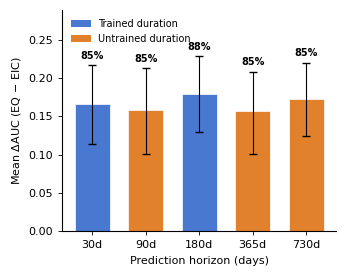

In [20]:
# Figure A: Per-duration delta AUC bar chart
fig, ax = plt.subplots(figsize=(3.5, 2.8))

means, los, his, win_rates, colors_list = [], [], [], [], []
color_id = "#4878CF"
color_ood = "#E1812C"

for dur in DURATIONS:
    sub = joined.filter(pl.col("duration_days") == dur)
    deltas = sub["delta_auc"].to_numpy()
    m = deltas.mean()
    lo, hi = bootstrap_ci(deltas)
    wr = 100 * (deltas > 0).sum() / len(deltas)
    means.append(m)
    los.append(m - lo)
    his.append(hi - m)
    win_rates.append(wr)
    colors_list.append(color_id if dur in TRAINED_DURATIONS else color_ood)

x = np.arange(len(DURATIONS))
bars = ax.bar(
    x, means, yerr=[los, his], capsize=3, color=colors_list,
    edgecolor="white", linewidth=0.5, width=0.65, error_kw={"linewidth": 0.8},
)

for i, (xi, m_val, wr) in enumerate(zip(x, means, win_rates)):
    ax.text(xi, m_val + his[i] + 0.006, f"{wr:.0f}%",
            ha="center", va="bottom", fontsize=7, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([f"{d}d" for d in DURATIONS])
ax.set_xlabel("Prediction horizon (days)")
ax.set_ylabel("Mean $\\Delta$AUC (EQ $-$ EIC)")
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax.set_ylim(0, max(means) + max(his) + 0.055)

legend_elements = [
    plt.Rectangle((0, 0), 1, 1, facecolor=color_id, edgecolor="none", label="Trained duration"),
    plt.Rectangle((0, 0), 1, 1, facecolor=color_ood, edgecolor="none", label="Untrained duration"),
]
ax.legend(handles=legend_elements, frameon=False, fontsize=7, loc="upper left",
          bbox_to_anchor=(0.0, 1.0))

fig.tight_layout()
plt.show()

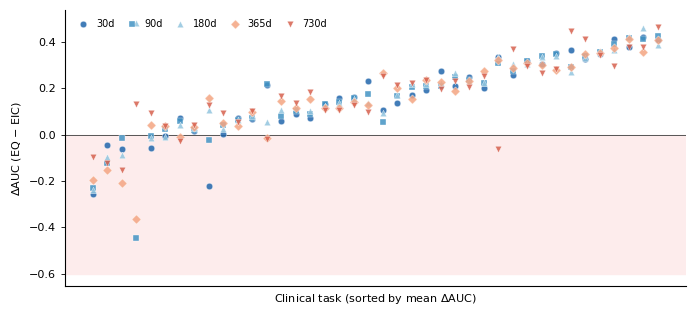

In [21]:
# Figure B: Task-level scatter (delta AUC by code, colored by duration)
code_order = (
    joined.group_by("code_slug")
    .agg(pl.col("delta_auc").mean().alias("mean_delta"))
    .sort("mean_delta")
)
code_list = code_order["code_slug"].to_list()
code_to_x = {c: i for i, c in enumerate(code_list)}

fig, ax = plt.subplots(figsize=(7, 3.2))

ax.axhspan(-0.6, 0, color="#FDECEC", zorder=0)

dur_colors = {30: "#2166AC", 90: "#4393C3", 180: "#92C5DE", 365: "#F4A582", 730: "#D6604D"}
dur_markers = {30: "o", 90: "s", 180: "^", 365: "D", 730: "v"}

for dur in DURATIONS:
    sub = joined.filter(pl.col("duration_days") == dur)
    xs = [code_to_x[c] for c in sub["code_slug"].to_list()]
    ys = sub["delta_auc"].to_numpy()
    ax.scatter(
        xs, ys, c=dur_colors[dur], marker=dur_markers[dur], s=22, alpha=0.85,
        edgecolors="white", linewidths=0.3, label=f"{dur}d", zorder=3,
    )

ax.axhline(0, color="#555555", linewidth=0.7, linestyle="-", zorder=2)
ax.set_xlabel("Clinical task (sorted by mean $\\Delta$AUC)")
ax.set_ylabel("$\\Delta$AUC (EQ $-$ EIC)")
ax.set_xticks([])
ax.legend(frameon=False, fontsize=7, ncol=5, loc="upper left",
          handletextpad=0.3, columnspacing=0.8)

fig.tight_layout()
plt.show()

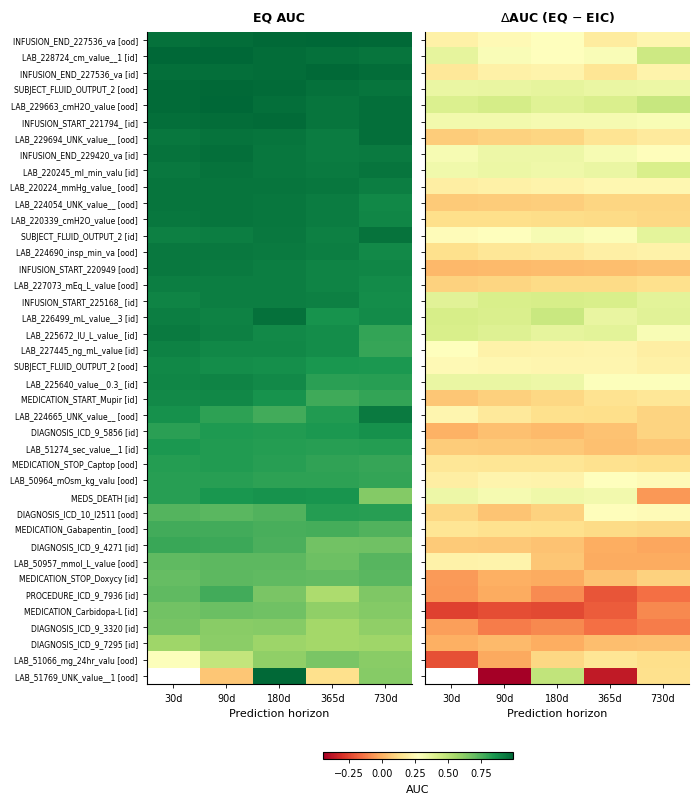

In [22]:
# Figure C: Heatmap dual panel (EQ AUC + delta AUC)
eq_for_heat = joined.select("code_slug", "duration_days", "occurs_auc", "delta_auc", "bucket")

code_sort = (
    eq_for_heat.group_by("code_slug")
    .agg(pl.col("occurs_auc").mean().alias("mean_eq_auc"))
    .sort("mean_eq_auc", descending=True)
)
sorted_codes = code_sort["code_slug"].to_list()

n_codes = len(sorted_codes)
n_durs = len(DURATIONS)
eq_matrix = np.full((n_codes, n_durs), np.nan)
delta_matrix = np.full((n_codes, n_durs), np.nan)
bucket_labels = []

for i, slug in enumerate(sorted_codes):
    sub = eq_for_heat.filter(pl.col("code_slug") == slug)
    bucket_labels.append(sub["bucket"][0])
    for j, dur in enumerate(DURATIONS):
        row = sub.filter(pl.col("duration_days") == dur)
        if len(row) > 0:
            eq_matrix[i, j] = row["occurs_auc"][0]
            delta_matrix[i, j] = row["delta_auc"][0]


def short_label(slug, bkt):
    parts = slug.rsplit("__", 1)
    name = parts[0][:22]
    tag = "id" if bkt == "id" else "ood"
    return f"{name} [{tag}]"


y_labels = [short_label(s, b) for s, b in zip(sorted_codes, bucket_labels)]

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(7, 11),
    gridspec_kw={"width_ratios": [1, 1], "wspace": 0.05},
)

cmap = "RdYlGn"
vmin = min(np.nanmin(eq_matrix), np.nanmin(delta_matrix))
vmax = max(np.nanmax(eq_matrix), np.nanmax(delta_matrix))

im1 = ax1.imshow(eq_matrix, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
ax1.set_xticks(range(n_durs))
ax1.set_xticklabels([f"{d}d" for d in DURATIONS], fontsize=7)
ax1.set_yticks(range(n_codes))
ax1.set_yticklabels(y_labels, fontsize=5.5)
ax1.set_title("EQ AUC", fontsize=9, fontweight="bold", pad=8)
ax1.set_xlabel("Prediction horizon")

im2 = ax2.imshow(delta_matrix, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
ax2.set_xticks(range(n_durs))
ax2.set_xticklabels([f"{d}d" for d in DURATIONS], fontsize=7)
ax2.set_yticks(range(n_codes))
ax2.set_yticklabels([], fontsize=5.5)
ax2.set_title("$\\Delta$AUC (EQ $-$ EIC)", fontsize=9, fontweight="bold", pad=8)
ax2.set_xlabel("Prediction horizon")

cb = fig.colorbar(im1, ax=[ax1, ax2], shrink=0.35, pad=0.08, aspect=25, location="bottom")
cb.ax.tick_params(labelsize=7)
cb.set_label("AUC", fontsize=8)

plt.show()

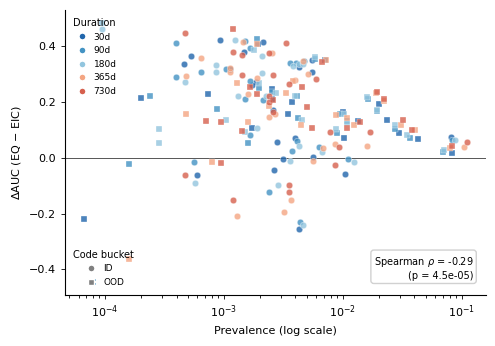

In [28]:
# Prevalence scatter
dur_colors_prev = {30: "#2166AC", 90: "#4393C3", 180: "#92C5DE", 365: "#F4A582", 730: "#D6604D"}
bucket_markers = {"id": "o", "ood": "s"}

# Pooled Spearman for annotation
rho_delta, p_delta = sp_stats.spearmanr(df["prevalence"].to_numpy(), df["delta_auc"].to_numpy())

fig, ax = plt.subplots(figsize=(5, 3.5))

for dur in DURATIONS:
    for bkt, marker in bucket_markers.items():
        sub = df.filter((pl.col("duration_days") == dur) & (pl.col("bucket") == bkt))
        if len(sub) == 0:
            continue
        ax.scatter(
            sub["prevalence"].to_numpy(), sub["delta_auc"].to_numpy(),
            c=dur_colors_prev[dur], marker=marker, s=22, alpha=0.8,
            edgecolors="white", linewidths=0.3, zorder=3,
        )

legend_dur = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=dur_colors_prev[d],
           markersize=5, label=f"{d}d")
    for d in DURATIONS
]
legend_bkt = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markersize=5, label="ID"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="gray", markersize=5, label="OOD"),
]

ax.axhline(0, color="#555555", linewidth=0.7, linestyle="-", zorder=1)
ax.set_xscale("log")
ax.set_xlabel("Prevalence (log scale)")
ax.set_ylabel("$\\Delta$AUC (EQ $-$ EIC)")

ax.text(
    0.97, 0.05, f"Spearman $\\rho$ = {rho_delta:+.2f}\n(p = {p_delta:.1e})",
    transform=ax.transAxes, ha="right", va="bottom", fontsize=7,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#cccccc", alpha=0.9),
)

leg1 = ax.legend(
    handles=legend_dur, frameon=False, fontsize=6.5, loc="upper left",
    title="Duration", title_fontsize=7, handletextpad=0.3,
)
ax.add_artist(leg1)
ax.legend(
    handles=legend_bkt, frameon=False, fontsize=6.5, loc="lower left",
    title="Code bucket", title_fontsize=7, handletextpad=0.3,
)

fig.tight_layout()
plt.show()

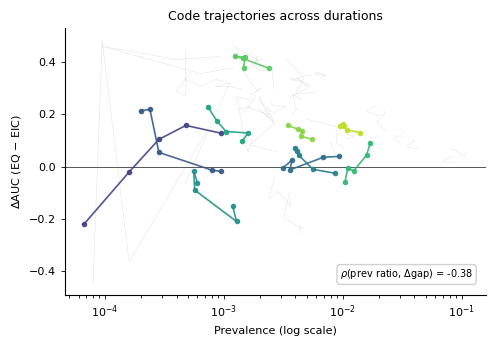

In [24]:
# Prevalence trajectories
code_traj = (
    df.filter(pl.col("duration_days").is_in([30, 730]))
    .group_by("code_slug")
    .agg(
        pl.col("prevalence").filter(pl.col("duration_days") == 30).first().alias("prev_30"),
        pl.col("prevalence").filter(pl.col("duration_days") == 730).first().alias("prev_730"),
        pl.col("delta_auc").filter(pl.col("duration_days") == 30).first().alias("delta_30"),
        pl.col("delta_auc").filter(pl.col("duration_days") == 730).first().alias("delta_730"),
        pl.col("bucket").first().alias("bucket"),
    )
    .filter(pl.col("prev_30").is_not_null() & pl.col("prev_730").is_not_null())
    .with_columns(
        (pl.col("prev_730") / pl.col("prev_30")).alias("prev_ratio"),
        (pl.col("delta_730") - pl.col("delta_30")).alias("delta_change"),
    )
    .sort("prev_ratio", descending=True)
)

ratios = code_traj["prev_ratio"].to_numpy()
delta_changes = code_traj["delta_change"].to_numpy()
rho_traj, p_traj = sp_stats.spearmanr(ratios, delta_changes)

fig, ax = plt.subplots(figsize=(5, 3.5))

# All codes as faint background
all_codes = df["code_slug"].unique().to_list()
for slug in all_codes:
    sub = df.filter(pl.col("code_slug") == slug).sort("duration_days")
    if len(sub) < 2:
        continue
    ax.plot(
        sub["prevalence"].to_numpy(), sub["delta_auc"].to_numpy(),
        color="#cccccc", linewidth=0.4, alpha=0.5, zorder=1,
    )

# Highlight top-10 codes with biggest prevalence shift
top_codes = code_traj.head(10)["code_slug"].to_list()
cmap_lines = plt.cm.viridis(np.linspace(0.2, 0.9, len(top_codes)))
for i, slug in enumerate(top_codes):
    sub = df.filter(pl.col("code_slug") == slug).sort("duration_days")
    ax.plot(
        sub["prevalence"].to_numpy(), sub["delta_auc"].to_numpy(),
        color=cmap_lines[i], linewidth=1.2, alpha=0.9, zorder=3, marker="o", markersize=3,
    )

ax.axhline(0, color="#555555", linewidth=0.7, linestyle="-", zorder=2)
ax.set_xscale("log")
ax.set_xlabel("Prevalence (log scale)")
ax.set_ylabel("$\\Delta$AUC (EQ $-$ EIC)")
ax.set_title("Code trajectories across durations", fontsize=9)
ax.text(
    0.97, 0.05, f"$\\rho$(prev ratio, $\\Delta$gap) = {rho_traj:+.2f}",
    transform=ax.transAxes, ha="right", va="bottom", fontsize=7,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#cccccc", alpha=0.9),
)

fig.tight_layout()
plt.show()

## Per-Duration Spearman Correlations

In [25]:
per_dur_rows = []
for dur in DURATIONS:
    sub = df.filter(pl.col("duration_days") == dur)
    p_arr = sub["prevalence"].to_numpy()
    d_arr = sub["delta_auc"].to_numpy()
    e_arr = sub["occurs_auc"].to_numpy()
    i_arr = sub["eic_auc"].to_numpy()

    r1, p1 = sp_stats.spearmanr(p_arr, d_arr)
    r2, p2 = sp_stats.spearmanr(p_arr, e_arr)
    r3, p3 = sp_stats.spearmanr(p_arr, i_arr)

    per_dur_rows.append({"duration": dur, "metric": "rho(prev, delta_auc)", "rho": round(r1, 3), "p_value": p1})
    per_dur_rows.append({"duration": dur, "metric": "rho(prev, EQ_auc)", "rho": round(r2, 3), "p_value": p2})
    per_dur_rows.append({"duration": dur, "metric": "rho(prev, EIC_auc)", "rho": round(r3, 3), "p_value": p3})

pl.DataFrame(per_dur_rows)

duration,metric,rho,p_value
i64,str,f64,f64
30,"""rho(prev, delta_auc)""",-0.348,0.030025
30,"""rho(prev, EQ_auc)""",0.186,0.256761
30,"""rho(prev, EIC_auc)""",0.643,0.00001
90,"""rho(prev, delta_auc)""",-0.213,0.187727
90,"""rho(prev, EQ_auc)""",0.195,0.227671
…,…,…,…
365,"""rho(prev, EQ_auc)""",0.14,0.389857
365,"""rho(prev, EIC_auc)""",0.527,0.000478
730,"""rho(prev, delta_auc)""",-0.25,0.119356


## Analysis 7: Embedding Analysis with Multi-Duration Queries

In [ ]:
import seaborn as sns
import umap
from sklearn.metrics.pairwise import cosine_similarity

FIG_DIR = REPO / "analysis" / "figures"

EMBED_PARQUET = (
    EQ_MODEL_DIR / "eval" / "best"
    / "eval_embeds_10000_ID__8db2be6fadf8_20260413_201311.parquet"
)
HOSP_EMBED_PARQUET = (
    EQ_MODEL_DIR / "eval" / "best"
    / "eval_embeds_hosp_admin_codes_20260414_015447.parquet"
)

### Step 1: Schema Exploration

In [ ]:
# Schema
schema = pl.read_parquet_schema(EMBED_PARQUET)
print("Columns and dtypes:")
for col_name, dtype in schema.items():
    print(f"  {col_name}: {dtype}")

# Lightweight aggregations via lazy scan (no embeddings in memory)
lf = pl.scan_parquet(EMBED_PARQUET)

row_count = lf.select(pl.len()).collect().item()
print(f"\nTotal rows: {row_count:,}")

summary = (
    lf.select("subject_id", "code", "duration_days")
    .collect()
)

n_subjects = summary["subject_id"].n_unique()
n_codes = summary["code"].n_unique()
durations_found = sorted(summary["duration_days"].unique().to_list())

print(f"Unique subjects: {n_subjects:,}")
print(f"Unique codes: {n_codes}")
print(f"Durations: {durations_found}")

# Per-(code, duration) counts
counts = (
    summary.group_by("code", "duration_days")
    .agg(pl.len().alias("n"))
    .sort("code", "duration_days")
)
print(f"\nPer-(code, duration) group counts (first 15):")
print(counts.head(15))

### Step 2: Subsample Query Codes and Patients

In [ ]:
# Seven query codes spanning different clinical categories
QUERY_CODES = {
    "Lab: PT": "LAB//51274//sec//value_[14.1,15.3)",
    "Lab: Osmolality": "LAB//50964//mOsm/kg//value_[288.0,293.0)",
    "Dx: Afib": "DIAGNOSIS//ICD//9//4271",
    "Dx: CKD": "DIAGNOSIS//ICD//9//5856",
    "Med: Gabapentin": "MEDICATION//Gabapentin//Delayed Administered",
    "Med: Captopril stop": "MEDICATION//STOP//Captopril",
    "Death": "MEDS_DEATH",
}
CODE_TO_LABEL = {v: k for k, v in QUERY_CODES.items()}
SELECTED_CODES = list(QUERY_CODES.values())
N_SAMPLE = 150

# Remap duration 731 -> 730 to match notebook convention
dur_remap = (
    pl.when(pl.col("duration_days") == 731)
    .then(pl.lit(730))
    .otherwise(pl.col("duration_days"))
    .alias("duration_days")
)

# Step 1: Find subjects present at all 5 durations for the selected codes
# (load only metadata columns, not embeddings)
meta = (
    pl.scan_parquet(EMBED_PARQUET)
    .filter(pl.col("code").is_in(SELECTED_CODES))
    .with_columns(dur_remap)
    .select("subject_id", "code", "duration_days")
    .collect()
)

# Subjects present at all 5 durations (for any single code -- they're the same across codes)
dur_coverage = (
    meta.filter(pl.col("code") == SELECTED_CODES[0])
    .group_by("subject_id")
    .agg(pl.col("duration_days").n_unique().alias("n_durs"))
    .filter(pl.col("n_durs") == 5)
)
eligible_subjects = dur_coverage["subject_id"]
print(f"Subjects with all 5 durations: {len(eligible_subjects):,}")

# Sample N_SAMPLE subjects
np.random.seed(42)
sampled_ids = np.random.choice(
    eligible_subjects.to_numpy(), size=min(N_SAMPLE, len(eligible_subjects)), replace=False
)
sample_df = pl.DataFrame({"subject_id": sampled_ids})

# Collect embeddings for sampled subjects x selected codes x all durations
embed_df = (
    pl.scan_parquet(EMBED_PARQUET)
    .filter(pl.col("code").is_in(SELECTED_CODES))
    .with_columns(dur_remap)
    .join(sample_df.lazy(), on="subject_id", how="semi")
    .select("subject_id", "code", "duration_days", "embedding")
    .collect()
)

# Add short label column
embed_df = embed_df.with_columns(
    pl.col("code").replace(CODE_TO_LABEL).alias("label")
)

# Extract numpy matrix
embed_mat = np.stack(embed_df["embedding"].to_list())

print(f"Embedding matrix shape: {embed_mat.shape}")
print(f"Unique codes: {embed_df['label'].n_unique()}")
print(f"Unique durations: {sorted(embed_df['duration_days'].unique().to_list())}")
print(f"Unique subjects: {embed_df['subject_id'].n_unique()}")
print(f"\nRows per (label, duration):")
print(
    embed_df.group_by("label", "duration_days")
    .agg(pl.len().alias("n"))
    .sort("label", "duration_days")
)

### Step 3: UMAP Projections

In [ ]:
reducer = umap.UMAP(
    n_neighbors=30, min_dist=0.3, metric="cosine",
    random_state=42, n_jobs=1,
)
umap_2d = reducer.fit_transform(embed_mat)

embed_df = embed_df.with_columns(
    pl.Series("umap_x", umap_2d[:, 0]),
    pl.Series("umap_y", umap_2d[:, 1]),
)
print(f"UMAP projection shape: {umap_2d.shape}")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(7, 2.5))

# Shared plot kwargs
scatter_kw = dict(s=3, alpha=0.5, edgecolors="none", rasterized=True)

# --- Panel (a): Color by query code ---
ax = axes[0]
code_labels = sorted(embed_df["label"].unique().to_list())
cmap = plt.cm.tab10
code_colors = {label: cmap(i) for i, label in enumerate(code_labels)}
for label in code_labels:
    mask = embed_df["label"].to_numpy() == label
    ax.scatter(umap_2d[mask, 0], umap_2d[mask, 1],
               color=code_colors[label], label=label, **scatter_kw)
ax.legend(fontsize=4.5, markerscale=2, loc="best", framealpha=0.7,
          handletextpad=0.3, borderpad=0.3)
ax.set_title("(a) Colored by query code", fontsize=8)
ax.set_xticks([])
ax.set_yticks([])

# --- Panel (b): Color by duration ---
ax = axes[1]
dur_colors = {30: "#2166AC", 90: "#4393C3", 180: "#92C5DE", 365: "#F4A582", 730: "#D6604D"}
dur_arr = embed_df["duration_days"].to_numpy()
for dur in DURATIONS:
    mask = dur_arr == dur
    ax.scatter(umap_2d[mask, 0], umap_2d[mask, 1],
               color=dur_colors[dur], label=f"{dur}d", **scatter_kw)
ax.legend(fontsize=5, markerscale=2, loc="best", framealpha=0.7,
          handletextpad=0.3, borderpad=0.3)
ax.set_title("(b) Colored by duration", fontsize=8)
ax.set_xticks([])
ax.set_yticks([])

# --- Panel (c): Color by patient ---
ax = axes[2]
subj_arr = embed_df["subject_id"].to_numpy()
unique_subjs = np.unique(subj_arr)
rng = np.random.RandomState(0)
subj_color_map = {s: plt.cm.hsv(rng.random()) for s in unique_subjs}
colors = [subj_color_map[s] for s in subj_arr]
ax.scatter(umap_2d[:, 0], umap_2d[:, 1], c=colors, **scatter_kw)
ax.set_title("(c) Colored by patient", fontsize=8)
ax.set_xticks([])
ax.set_yticks([])
ax.annotate("No patient clustering", xy=(0.5, 0.02),
            xycoords="axes fraction", ha="center", fontsize=6,
            fontstyle="italic", color="0.3")

fig.tight_layout()
fig.savefig(FIG_DIR / "fig_embed_umap.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "fig_embed_umap.png", bbox_inches="tight", dpi=300)
plt.show()

### Step 4: Cosine Similarity Distributions

In [ ]:
MAX_PAIRS = 50_000
rng = np.random.RandomState(42)

labels_arr = embed_df["label"].to_numpy()
dur_arr = embed_df["duration_days"].to_numpy()
subj_arr = embed_df["subject_id"].to_numpy()

# Build index: (label, duration) -> row indices
from collections import defaultdict
group_idx = defaultdict(list)
for i in range(len(embed_df)):
    group_idx[(labels_arr[i], dur_arr[i])].append(i)

# Also build per-subject index: subject_id -> list of row indices
subj_idx = defaultdict(list)
for i in range(len(embed_df)):
    subj_idx[subj_arr[i]].append(i)

sim_groups = {}

# --- Group 1: Same code, same duration, different patients ---
sims = []
for (label, dur), idxs in group_idx.items():
    if len(idxs) < 2:
        continue
    mat = embed_mat[idxs]
    cs = cosine_similarity(mat)
    # Upper triangle (excluding diagonal)
    triu = cs[np.triu_indices_from(cs, k=1)]
    sims.append(triu)
sims = np.concatenate(sims)
if len(sims) > MAX_PAIRS:
    sims = rng.choice(sims, size=MAX_PAIRS, replace=False)
sim_groups["Same code\nsame duration"] = sims
print(f"Group 1 (same code, same dur): {len(sims):,} pairs, "
      f"mean={sims.mean():.4f}, std={sims.std():.4f}")

# --- Group 2: Same code, different duration, different patients ---
sims = []
code_labels_unique = sorted(set(labels_arr))
for label in code_labels_unique:
    durs_for_code = sorted(set(d for (l, d) in group_idx if l == label))
    for di, d1 in enumerate(durs_for_code):
        for d2 in durs_for_code[di + 1:]:
            idxs1 = group_idx[(label, d1)]
            idxs2 = group_idx[(label, d2)]
            # Get subject arrays for masking same-patient pairs
            subjs1 = subj_arr[idxs1]
            subjs2 = subj_arr[idxs2]
            cs = cosine_similarity(embed_mat[idxs1], embed_mat[idxs2])
            # Mask same-patient pairs
            same_patient = subjs1[:, None] == subjs2[None, :]
            diff_patient_sims = cs[~same_patient]
            sims.append(diff_patient_sims)
sims = np.concatenate(sims)
if len(sims) > MAX_PAIRS:
    sims = rng.choice(sims, size=MAX_PAIRS, replace=False)
sim_groups["Same code\ndiff duration"] = sims
print(f"Group 2 (same code, diff dur): {len(sims):,} pairs, "
      f"mean={sims.mean():.4f}, std={sims.std():.4f}")

# --- Group 3: Same patient, different codes (any duration) ---
sims = []
for subj, idxs in subj_idx.items():
    if len(idxs) < 2:
        continue
    codes_for_subj = labels_arr[idxs]
    unique_codes = np.unique(codes_for_subj)
    if len(unique_codes) < 2:
        continue
    # Pick pairs from different codes
    for ci, c1 in enumerate(unique_codes):
        for c2 in unique_codes[ci + 1:]:
            rows1 = [idx for idx in idxs if labels_arr[idx] == c1]
            rows2 = [idx for idx in idxs if labels_arr[idx] == c2]
            cs = cosine_similarity(embed_mat[rows1], embed_mat[rows2])
            sims.append(cs.ravel())
sims = np.concatenate(sims)
if len(sims) > MAX_PAIRS:
    sims = rng.choice(sims, size=MAX_PAIRS, replace=False)
sim_groups["Same patient\ndiff code"] = sims
print(f"Group 3 (same patient, diff code): {len(sims):,} pairs, "
      f"mean={sims.mean():.4f}, std={sims.std():.4f}")

# --- Group 4: Different code, different duration, different patient (baseline) ---
all_keys = list(group_idx.keys())
sims = []
n_needed = MAX_PAIRS
while len(sims) < n_needed:
    batch = min(n_needed - len(sims), 10_000)
    ki1 = rng.randint(0, len(all_keys), size=batch)
    ki2 = rng.randint(0, len(all_keys), size=batch)
    for a, b in zip(ki1, ki2):
        k1, k2 = all_keys[a], all_keys[b]
        if k1[0] == k2[0] or k1[1] == k2[1]:
            continue  # require different code AND different duration
        i1 = rng.choice(group_idx[k1])
        i2 = rng.choice(group_idx[k2])
        if subj_arr[i1] == subj_arr[i2]:
            continue  # require different patient
        sims.append(float(cosine_similarity(
            embed_mat[i1:i1+1], embed_mat[i2:i2+1]
        )))
        if len(sims) >= n_needed:
            break
sims = np.array(sims)
sim_groups["Baseline\n(all differ)"] = sims
print(f"Group 4 (baseline): {len(sims):,} pairs, "
      f"mean={sims.mean():.4f}, std={sims.std():.4f}")

In [ ]:
# Violin plot
group_order = [
    "Same code\nsame duration",
    "Same code\ndiff duration",
    "Same patient\ndiff code",
    "Baseline\n(all differ)",
]
palette = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

plot_data = []
for g in group_order:
    for v in sim_groups[g]:
        plot_data.append({"Group": g, "Cosine similarity": float(v)})
plot_df = pl.DataFrame(plot_data).to_pandas()

fig, ax = plt.subplots(figsize=(3.5, 3.0))
sns.violinplot(
    data=plot_df, x="Group", y="Cosine similarity",
    order=group_order, palette=palette, inner="box",
    linewidth=0.8, ax=ax, cut=0,
)
ax.set_xlabel("")
ax.set_ylabel("Cosine similarity", fontsize=8)
ax.tick_params(axis="x", labelsize=6.5)
ax.tick_params(axis="y", labelsize=7)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_embed_cosine_sim.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "fig_embed_cosine_sim.png", bbox_inches="tight", dpi=300)
plt.show()

# Summary statistics
print(f"{'Group':<28} {'Mean':>7} {'Median':>7} {'Std':>7}")
print("-" * 55)
for g in group_order:
    vals = sim_groups[g]
    print(f"{g.replace(chr(10), ', '):<28} {vals.mean():>7.4f} "
          f"{np.median(vals):>7.4f} {vals.std():>7.4f}")

# Mann-Whitney U tests between adjacent groups
from scipy.stats import mannwhitneyu
print("\nMann-Whitney U tests (adjacent groups):")
for i in range(len(group_order) - 1):
    g1, g2 = group_order[i], group_order[i + 1]
    stat, pval = mannwhitneyu(sim_groups[g1], sim_groups[g2], alternative="greater")
    label1 = g1.replace("\n", ", ")
    label2 = g2.replace("\n", ", ")
    print(f"  {label1} > {label2}: U={stat:.0f}, p={pval:.2e}")

### Step 5: Hospital Admission Embeddings UMAP

In [ ]:
# Sample 200 subjects from hospital admission embeddings
hosp_subjects = (
    pl.scan_parquet(HOSP_EMBED_PARQUET)
    .select("subject_id")
    .unique()
    .collect()
    .sample(n=200, seed=42)
)

hosp_df = (
    pl.scan_parquet(HOSP_EMBED_PARQUET)
    .join(hosp_subjects.lazy(), on="subject_id", how="semi")
    .select("subject_id", "code", "duration_days", "embedding")
    .collect()
)
print(f"Hospital embedding rows: {len(hosp_df):,}")
print(f"Unique codes: {hosp_df['code'].n_unique()}")

# Parse admission type and referral source from code string
# Format: HOSPITAL_ADMISSION//admission_type//referral_source  (or MEDS_DEATH)
hosp_df = hosp_df.with_columns(
    pl.when(pl.col("code").str.starts_with("HOSPITAL_ADMISSION"))
    .then(pl.col("code").str.split("//").list.get(1))
    .otherwise(pl.lit("MORTALITY"))
    .alias("admission_type"),
    pl.when(pl.col("code").str.starts_with("HOSPITAL_ADMISSION"))
    .then(pl.col("code").str.split("//").list.get(2))
    .otherwise(pl.lit("N/A"))
    .alias("referral_source"),
)

hosp_mat = np.stack(hosp_df["embedding"].to_list())
print(f"Hospital embedding matrix: {hosp_mat.shape}")

# Print code distribution
print(f"\nAdmission types: {sorted(hosp_df['admission_type'].unique().to_list())}")
print(f"Referral sources: {sorted(hosp_df['referral_source'].unique().to_list())}")

# Run UMAP
hosp_reducer = umap.UMAP(
    n_neighbors=15, min_dist=0.3, metric="cosine",
    random_state=42, n_jobs=1,
)
hosp_umap_2d = hosp_reducer.fit_transform(hosp_mat)
hosp_df = hosp_df.with_columns(
    pl.Series("umap_x", hosp_umap_2d[:, 0]),
    pl.Series("umap_y", hosp_umap_2d[:, 1]),
)
print(f"Hospital UMAP done: {hosp_umap_2d.shape}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3.0))
scatter_kw = dict(s=3, alpha=0.4, edgecolors="none", rasterized=True)

# --- Panel (a): Color by admission type ---
ax = axes[0]
adm_types = sorted(hosp_df["admission_type"].unique().to_list())
adm_cmap = plt.cm.tab10 if len(adm_types) <= 10 else plt.cm.tab20
adm_colors = {t: adm_cmap(i) for i, t in enumerate(adm_types)}
adm_arr = hosp_df["admission_type"].to_numpy()
for t in adm_types:
    mask = adm_arr == t
    ax.scatter(hosp_umap_2d[mask, 0], hosp_umap_2d[mask, 1],
               color=adm_colors[t], label=t, **scatter_kw)
ax.legend(fontsize=4, markerscale=2, loc="best", framealpha=0.7,
          handletextpad=0.3, borderpad=0.3)
ax.set_title("(a) Colored by admission type", fontsize=8)
ax.set_xticks([])
ax.set_yticks([])

# --- Panel (b): Color by referral source ---
ax = axes[1]
ref_sources = sorted(hosp_df["referral_source"].unique().to_list())
ref_cmap = plt.cm.tab20
ref_colors = {s: ref_cmap(i) for i, s in enumerate(ref_sources)}
ref_arr = hosp_df["referral_source"].to_numpy()
for s in ref_sources:
    mask = ref_arr == s
    ax.scatter(hosp_umap_2d[mask, 0], hosp_umap_2d[mask, 1],
               color=ref_colors[s], label=s, **scatter_kw)
ax.legend(fontsize=3.5, markerscale=2, loc="best", framealpha=0.7,
          handletextpad=0.3, borderpad=0.3, ncol=2)
ax.set_title("(b) Colored by referral source", fontsize=8)
ax.set_xticks([])
ax.set_yticks([])

fig.tight_layout()
fig.savefig(FIG_DIR / "fig_embed_hosp_umap.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "fig_embed_hosp_umap.png", bbox_inches="tight", dpi=300)
plt.show()